In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import os

First, let's define a function that merges all the CSVs together and creates a single DataFrame (column-wise append)

In [153]:
def merge_csvs(path: str, features=[]) -> pd.DataFrame:
    all_files = []
    count = 0
    
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            if filename.endswith('.csv'):
                all_files.append(os.path.join(dirpath, filename))
                count += 1
                
    if len(features) == 0:
        return (pd.concat([pd.read_csv(f) for f in all_files]), count)
    
    filtered_files = [f for f in all_files if check_values_in_column(pd.read_csv(f), 'OpenAPI feature', features)]
    count = len(filtered_files)
    if count > 0:
        return (pd.concat([pd.read_csv(f) for f in filtered_files]), count)
    return pd.DataFrame(), 0
        
    
def check_values_in_column(df, column, values):
    return all(value in df[column].values for value in values)

In [154]:
df, num_dfs = merge_csvs("../../openapi-directory/CSVs/")

In [155]:
print(df)
print(num_dfs)

                           OpenAPI feature  Count
0                  SchemaExtension_Depth_3      0
1                         ResponseCode_200     47
2                                   Server      2
3                             OperationTag     47
4                        SchemaType_object    184
..                                     ...    ...
77                            Enum_Depth_3      0
78                                Encoding      0
79  RequestBodyContent_multipart/form-data      4
80                        MaxItems_Depth_1      2
81                           Items_Depth_2      4

[126773 rows x 2 columns]
1306


Now, let's define a few functions.

`filter_and_groupby` --> Given a DataFrame and specific OpenAPI feature, group by any columns that contain the feature string and sum over the resulting row set.

`filter_and_barchart` --> Plot a barchart of the resulting `groupby` and `sum` above. 

In [156]:
def filter_and_groupby(df: pd.DataFrame, f: str) -> pd.DataFrame:
    filteredDf = df[df['OpenAPI feature'].str.contains(f)]
    return filteredDf.groupby('OpenAPI feature').sum()

def filter_and_barchart(df: pd.DataFrame, f: str):
    filter_and_groupby(df, f).plot.bar()
    plt.show()


Cool, now we can visualize the bar charts to get a better sense of the distribution of security schemes, parameter types/styles, and schema types.

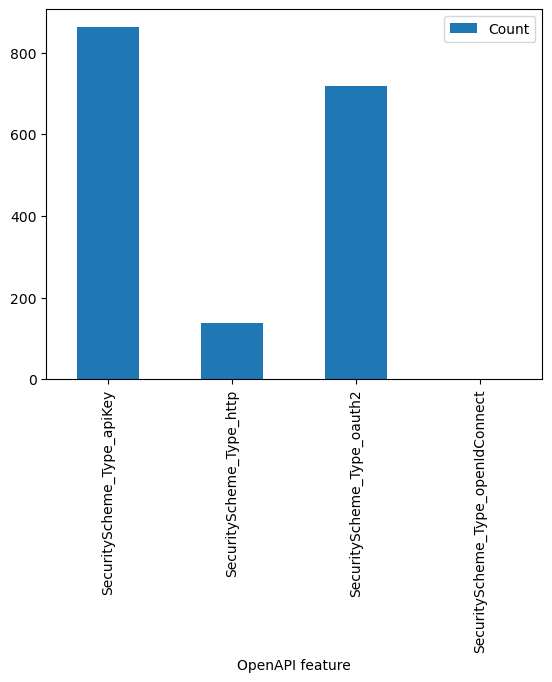

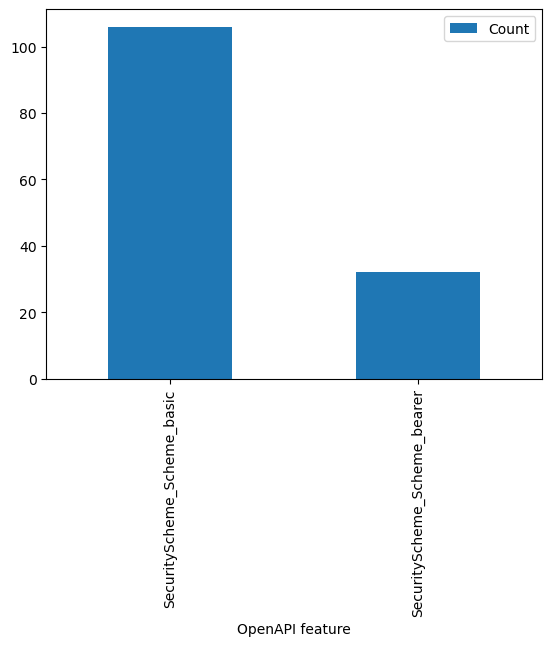

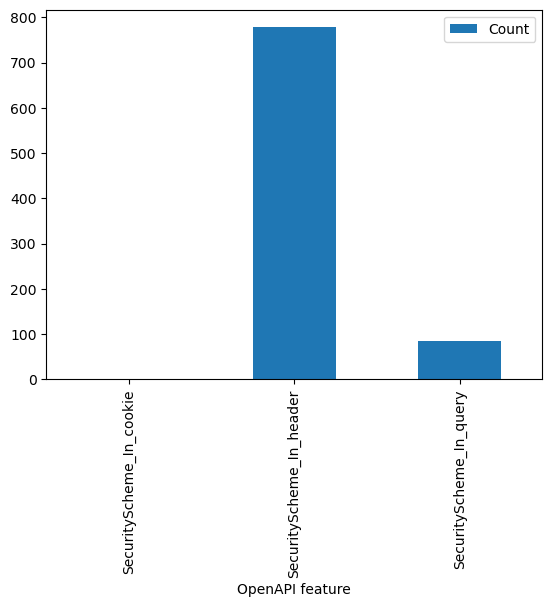

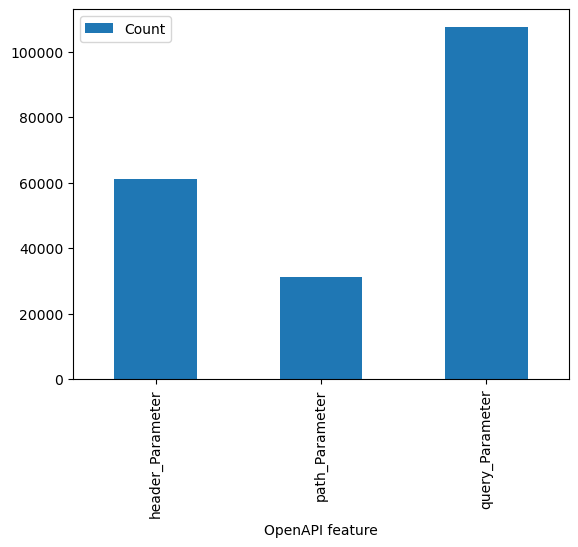

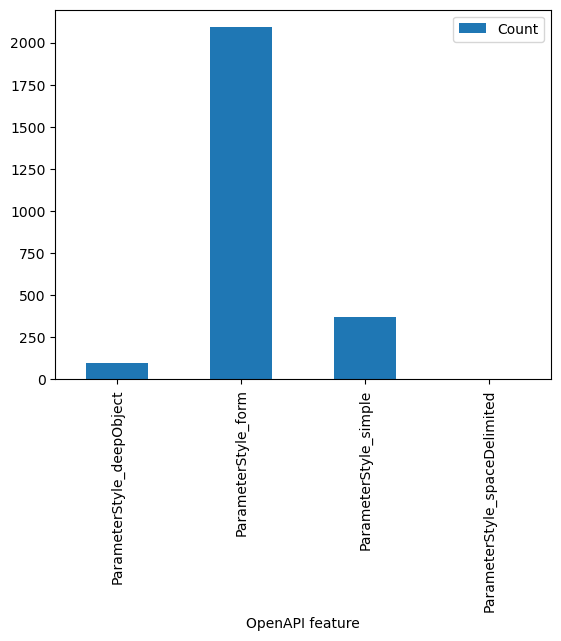

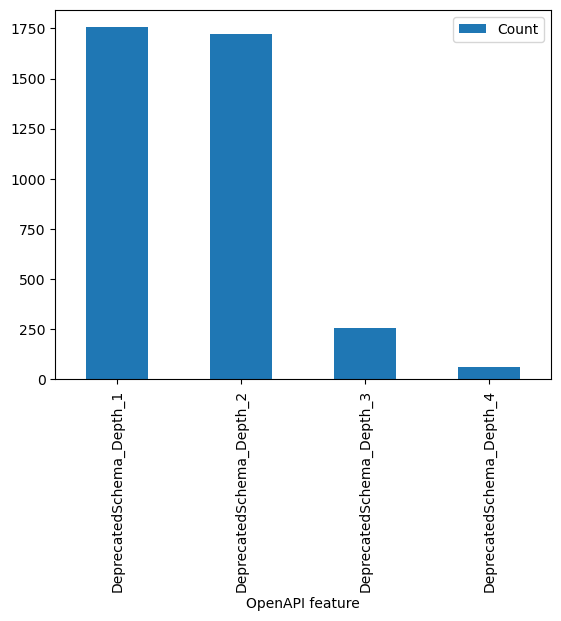

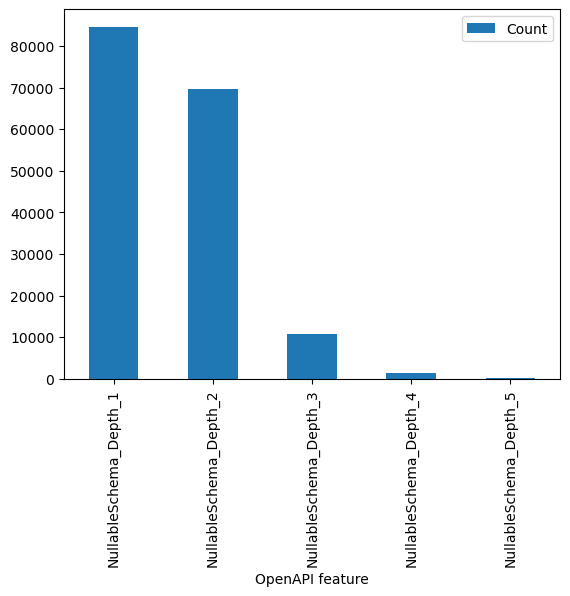

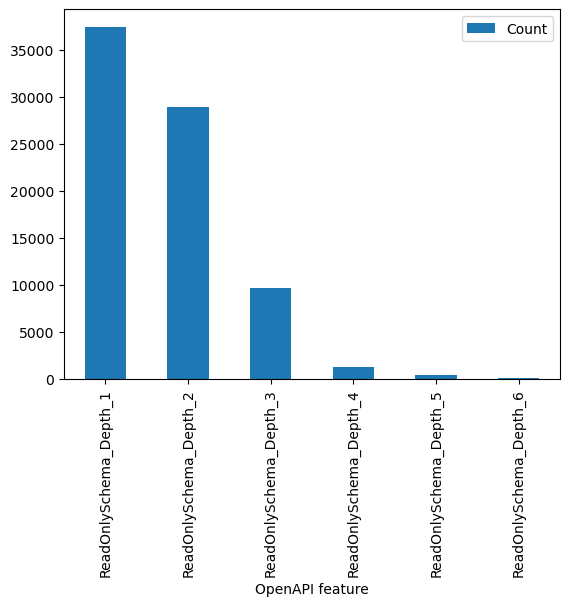

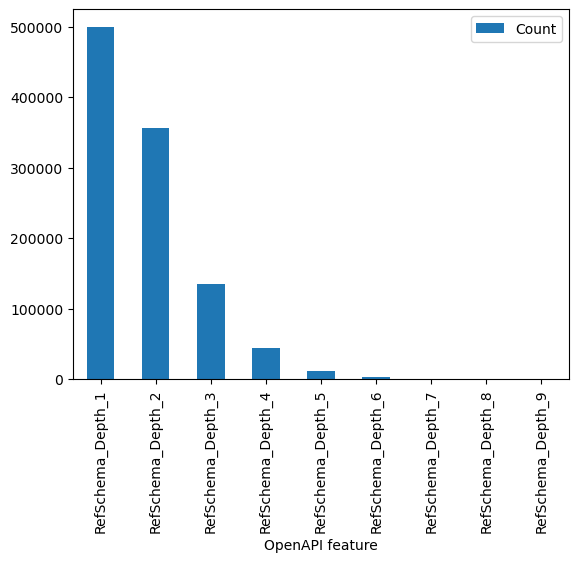

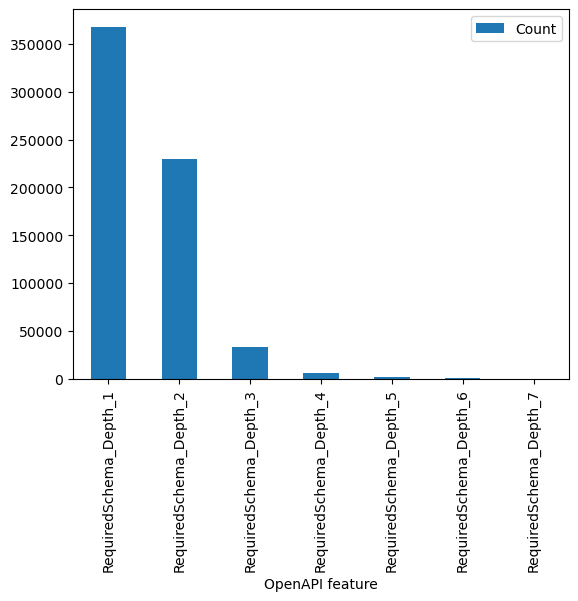

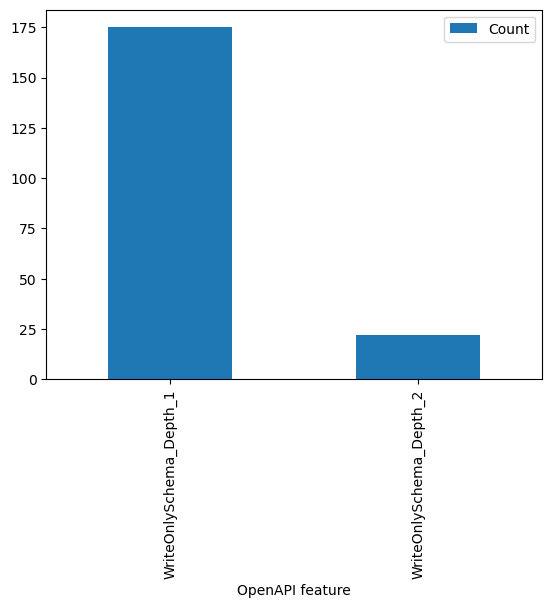

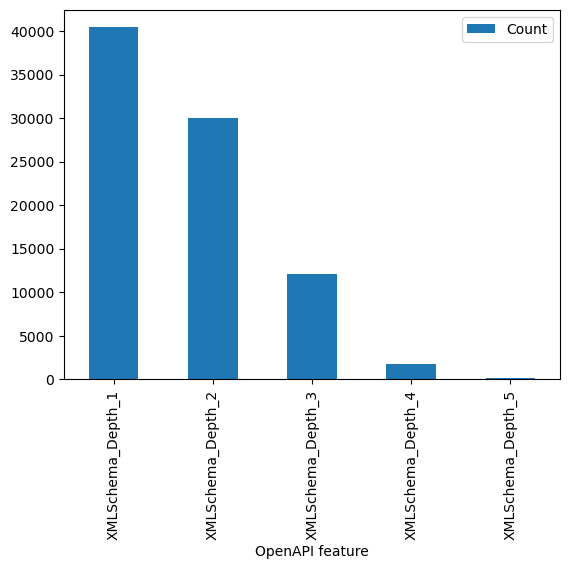

In [157]:
filter_and_barchart(df, 'SecurityScheme_Type')
filter_and_barchart(df, 'SecurityScheme_Scheme')
filter_and_barchart(df, 'SecurityScheme_In')

filter_and_barchart(df, '_Parameter')
filter_and_barchart(df, 'ParameterStyle_')

filter_and_barchart(df, 'DeprecatedSchema_Depth_')
filter_and_barchart(df, 'NullableSchema_Depth_')
filter_and_barchart(df, 'ReadOnlySchema_Depth_')
filter_and_barchart(df, 'RefSchema_Depth_')
filter_and_barchart(df, 'RequiredSchema_Depth_')
filter_and_barchart(df, 'WriteOnlySchema_Depth_')
filter_and_barchart(df, 'XMLSchema_Depth_')


Unfortunately, sometimes we have so many different features (ex. Request body content types) on the x-axis, that this doesn't lead to a nice visualization. Let's just see the distribution of the top 20 formats, response codes, and request body contents in a DataFrame without any visualization. 

In [158]:
formatDf = filter_and_groupby(df, 'Format_')
formatDf['format_prefix'] = formatDf.index.str.rsplit('_', 2).str[0]
print(formatDf.groupby(by='format_prefix').sum().nlargest(20, 'Count'))

print(filter_and_groupby(df, 'ResponseCode_').nlargest(20, 'Count'))

print(filter_and_groupby(df, 'RequestBodyContent_').nlargest(20, 'Count'))


                         Count
format_prefix                 
Format_int32            109619
Format_uri              103071
Format_date-time         69332
Format_int64             38064
Format_float             37787
Format_double            29849
Format_uuid              13330
Format_google-datetime   13258
Format_uri-reference      8651
Format_date               7824
Format_google-duration    7159
Format_uint32             5577
Format_byte               3312
Format_uint64             3035
Format_password           2341
Format_string             1474
Format_slug               1362
Format_constant           1286
Format_email              1215
Format_json-path          1139
                  Count
OpenAPI feature        
ResponseCode_200  30703
ResponseCode_480   8400
ResponseCode_481   7640
ResponseCode_404   6673
ResponseCode_482   6212
ResponseCode_400   5389
ResponseCode_401   5185
ResponseCode_483   4881
ResponseCode_403   3965
ResponseCode_500   3694
ResponseCode_484   3445
Respon

We should also define a function that allows us to see the distribution of the number of OpenAPI schemas that have different counts of a particular feature.

In [159]:
def filter_and_histogram(df: pd.DataFrame, f: str):
    filteredDf = df[df['OpenAPI feature'] == f]
    filteredDf['Count'].hist(bins=35)
    plt.xlabel(f)
    plt.ylabel("Number of OpenAPI Schemas")
    plt.show()

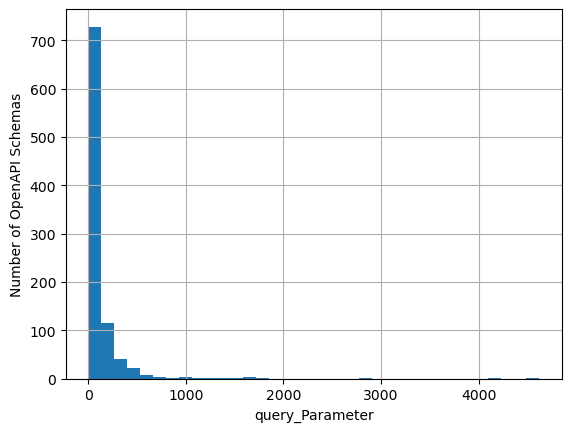

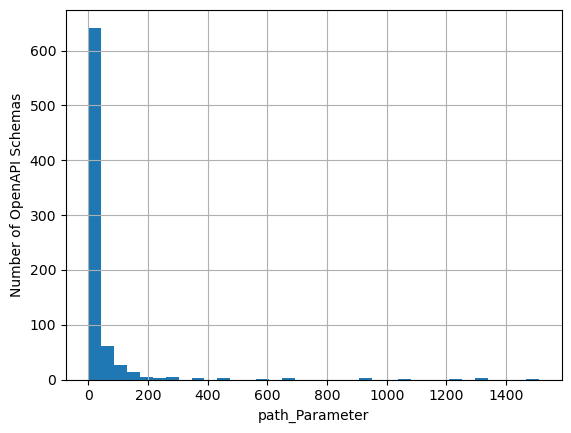

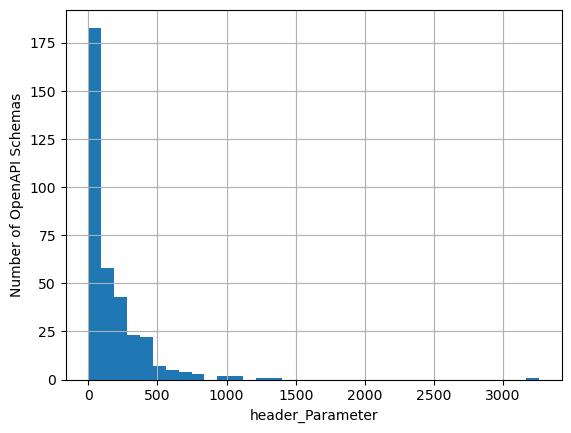

In [160]:
filter_and_histogram(df, 'query_Parameter')
filter_and_histogram(df, 'path_Parameter')
filter_and_histogram(df, 'header_Parameter')

Let's also define a few functions that help us:
- Count the number of CSVs that have a recorded instance of the specified OpenAPI feature
- Calculate the percentage of schemas that have this OpenAPI feature
- Calculate the percentage of this OpenAPI feature out of all possibilities for its prefix.
 Ex. `calc_pct_of_property_among_types(df, 'RequestBodyContent_application/json')` will calculate the percentage of request bodies that have `application/json` content type.

In [161]:
def count_csvs_with_property(feature: str, path="../../openapi-directory/CSVs/") -> int:
    all_files = []
    count = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            if filename.endswith('.csv'):
                all_files.append(os.path.join(dirpath, filename))

    for f in all_files:
        df = pd.read_csv(f)
        if (df[df["OpenAPI feature"] == feature]['Count'] > 0).any():
            count += 1
    return count
    
def count_csvs_containing_property(feature: str, path="../../openapi-directory/CSVs/") -> int:
    all_files = []
    count = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            if filename.endswith('.csv'):
                all_files.append(os.path.join(dirpath, filename))

    for f in all_files:
        df = pd.read_csv(f)
        if (df[df["OpenAPI feature"].str.contains(feature)]['Count'] > 0).any():
            count += 1
    return count

def calc_pct_of_property_in_schemas(feature: str) -> float:
    count = count_csvs_with_property(feature)
    return (count / num_dfs) * 100

def calc_pct_of_property_among_types(df: pd.DataFrame, feature: str, depth=False) -> float:
    filteredDf = filter_and_groupby(df, feature.rsplit('_', 1)[0] + '_')
    if depth is True:
        filteredDf['feature_prefix'] = filteredDf.index.str.rsplit('_', 2).str[0]
        filteredDf = filteredDf.groupby(by='feature_prefix').sum()
    filteredDf['feature_prefix'] = filteredDf.index
    return (filteredDf.loc[filteredDf['feature_prefix'] == feature, 'Count'].iat[0] / filteredDf['Count'].sum()) * 100

       

Now let's get the percentage of:
- request bodies and responses that have `application/json` content type.
- Nullable, deprecated, read-only, write-only, required, reference, and XML schemas

While we're at it, let's get the percentage of schemas that contain such properties as well.

In [162]:
print ("Percentage of schemas that contain an application/json request body: ", calc_pct_of_property_in_schemas("RequestBodyContent_application/json"))
print ("Percentage of request bodies that have application/json content type: ", calc_pct_of_property_among_types(df, "RequestBodyContent_application/json"))


print ("Percentage of schemas that contain an application/json response: ", calc_pct_of_property_in_schemas("ResponseContent_application/json"))
print ("Percentage of responses that have application/json content type: ", calc_pct_of_property_among_types(df, "ResponseContent_application/json"))

print ("Percentage of schemas that contain a nullable schema object: ", (count_csvs_containing_property("NullableSchema_")/num_dfs) * 100)
print ("Percentage of schemas that contain a deprecated schema object: ", (count_csvs_containing_property("DeprecatedSchema_")/num_dfs) * 100)
print ("Percentage of schemas that contain a required schema object: ", (count_csvs_containing_property("RequiredSchema_")/num_dfs) * 100)
print ("Percentage of schemas that contain a read-only schema object: ", (count_csvs_containing_property("ReadOnlySchema_")/num_dfs) * 100)





Percentage of schemas that contain an application/json request body:  74.19601837672282
Percentage of request bodies that have application/json content type:  71.6820479015601
Percentage of schemas that contain an application/json response:  91.42419601837672
Percentage of responses that have application/json content type:  78.7884514018041
Percentage of schemas that contain a nullable schema object:  11.791730474732006
Percentage of schemas that contain a deprecated schema object:  5.130168453292496
Percentage of schemas that contain a required schema object:  54.97702909647779
Percentage of schemas that contain a read-only schema object:  20.06125574272588


Let's also get the percentage of schemas that contain:
- Callbacks
- Webhooks
- Tags
- Encodings
- Examples

In [163]:
print ("Percentage of schemas that contain a callback: ", calc_pct_of_property_in_schemas("Callback"))
print ("Percentage of schemas that contain a webhook: ", calc_pct_of_property_in_schemas("GlobalWebhook"))
print ("Percentage of schemas that contain a tag (in any section): ", calc_pct_of_property_in_schemas("Tag"))
print ("Percentage of schemas that contain an encoding (in any section): ", calc_pct_of_property_in_schemas("Encoding"))
print ("Percentage of schemas that contain an example (in any section): ", calc_pct_of_property_in_schemas("Example"))


Percentage of schemas that contain a callback:  0.45941807044410415
Percentage of schemas that contain a webhook:  0.0
Percentage of schemas that contain a tag (in any section):  43.26186830015314
Percentage of schemas that contain an encoding (in any section):  0.0765696784073507
Percentage of schemas that contain an example (in any section):  38.28483920367535


Lets take a look at the schema types more closely

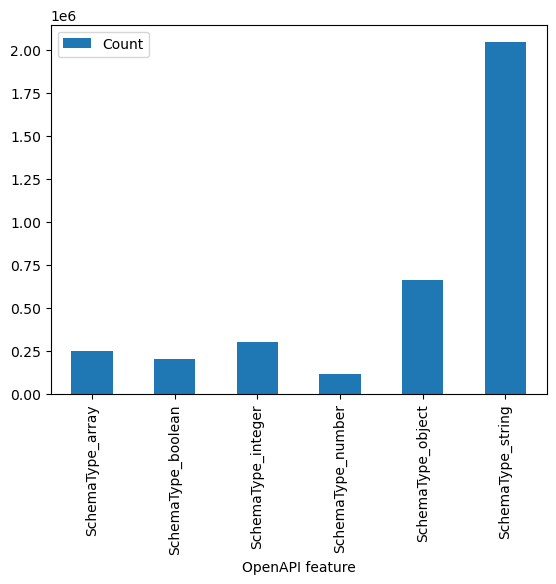

In [164]:
filter_and_barchart(df, "SchemaType_")

How many schemas contain multiple response content types?

In [165]:
def count_csvs_with_multiple_response_content_types(path="../../openapi-directory/CSVs/") -> int:
    all_files = []
    count = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            if filename.endswith('.csv'):
                all_files.append(os.path.join(dirpath, filename))

    for f in all_files:
        df = pd.read_csv(f)
        if (df[df["OpenAPI feature"].str.contains("ResponseContent_")].shape[0] > 1):
            count += 1
    return count

print ("Percentage of schemas that contain multiple response content types: ", (count_csvs_with_multiple_response_content_types()/num_dfs)*100)

Percentage of schemas that contain multiple response content types:  25.038284839203673


In [166]:
def is_success(status_code: str) -> bool:
    new_status_code = status_code.replace("XX", "00")
    if 200 <= int(new_status_code) < 300:
        # status code is successful
        return True
    # status code is not successful
    return False

def count_csvs_with_multiple_response_codes_success(path="../../openapi-directory/CSVs/") -> int:
    all_files = []
    count = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            if filename.endswith('.csv'):
                all_files.append(os.path.join(dirpath, filename))

    for f in all_files:
        df = pd.read_csv(f)
        df = filter_and_groupby(df, "ResponseCode_")
        df["status_code"] = df.index.str.rsplit("_", 1).str[-1]
        if (sum(df["status_code"].apply(is_success)) > 1):
            count += 1
    return count

print ("Percentage of schemas that contain multiple successful response codes: ", (count_csvs_with_multiple_response_codes_success()/num_dfs)*100)


Percentage of schemas that contain multiple successful response codes:  19.06584992343032


In [167]:
def is_error(status_code: str) -> bool:
    return not is_success(status_code)

def count_csvs_with_multiple_response_codes_error(path="../../openapi-directory/CSVs/") -> int:
    all_files = []
    count = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            if filename.endswith('.csv'):
                all_files.append(os.path.join(dirpath, filename))

    for f in all_files:
        df = pd.read_csv(f)
        df = filter_and_groupby(df, "ResponseCode_")
        df["status_code"] = df.index.str.rsplit("_", 1).str[-1]
        if (sum(df["status_code"].apply(is_error)) > 1):
            count += 1
    return count

print ("Percentage of schemas that contain multiple error response codes: ", (count_csvs_with_multiple_response_codes_error()/num_dfs)*100)

Percentage of schemas that contain multiple error response codes:  50.76569678407351


Let's create a more generic function to do this with multiple features

In [168]:
def count_csvs_with_features(features: [str], path="../../openapi-directory/CSVs/") -> int:
    all_files = []
    count = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            if filename.endswith('.csv'):
                all_files.append(os.path.join(dirpath, filename))

    for f in all_files:
        if check_values_in_column(pd.read_csv(f), "OpenAPI feature", features):
            count += 1
    return count


Do any OpenAPI schemas define both api key and oauth2 security schemes?

In [169]:
print(count_csvs_with_features(["SecurityScheme_Type_apiKey", "SecurityScheme_Type.oauth2"]))

0


What's the distribution of styles for application/x-www-form-urlencoded request bodies?

In [170]:
# We want to only include CSVs that have RequestBodyContent_application/x-www-form-urlencoded and then do a filter_and_groupby
#----- EXPERIMENTAL ---------------#

def merge_csvs_with_features(features: [str], path="../../openapi-directory/CSVs/") -> int:
    form_url_encoded_dfs, num_form_url_encoded_dfs = merge_csvs(path, features)
    print(form_url_encoded_dfs)
    filter_and_barchart(form_url_encoded_dfs, 'ParameterStyle_')
    return num_form_url_encoded_dfs

print("Number of CSVs with application/x-www-form-urlencoded request bodies", merge_csvs_with_features('RequestBodyContent_application/x-www-form-urlencoded'))

Empty DataFrame
Columns: []
Index: []


KeyError: 'OpenAPI feature'

Let's get the distribution of HTTP methods (GET vs. PUT vs. POST, etc)

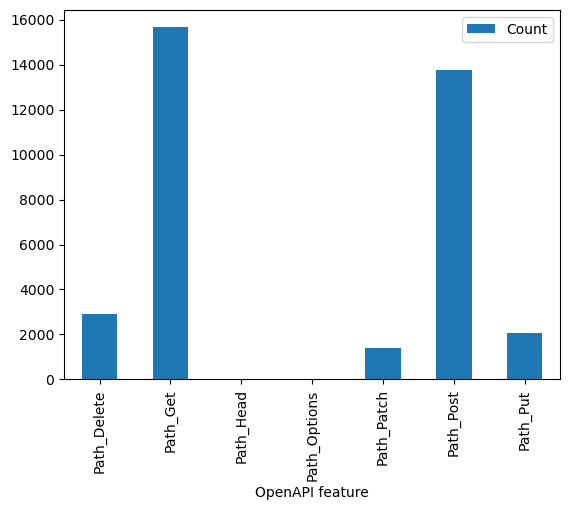

None


In [171]:
# def filter_method_rows(df: pd.DataFrame) -> pd.DataFrame:
#     verbs = {'_Get', '_Post', '_Put', '_Delete', '_Patch', '_Head', '_Options', '_Trace'}
#     return df[df['OpenAPI feature'].str.endswith(tuple(verbs))]

print(filter_and_barchart(df, 'Path_'))

In [172]:
# This is all CSVs with all feature counts added up merged in to 1 DataFrame
mergedDf = df.groupby("OpenAPI feature").sum()
print(mergedDf)

                                      Count
OpenAPI feature                            
AdditionalPropertiesAllowed_Depth_1    1670
AdditionalPropertiesAllowed_Depth_2     678
AdditionalPropertiesAllowed_Depth_3      78
AdditionalPropertiesAllowed_Depth_4     163
AdditionalPropertiesAllowed_Depth_5      80
...                                     ...
XMLSchema_Depth_5                       116
XMLWrapped                              290
header_Parameter                      61333
path_Parameter                        31122
query_Parameter                      107631

[1399 rows x 1 columns]
